In [11]:
import os
import operator
from datetime import date, timedelta
from pathlib import Path
from pydantic import BaseModel, Field
from typing import List, Literal, Optional, Annotated, TypedDict


from langchain_core.messages import SystemMessage, HumanMessage
from langgraph.graph import StateGraph, START, END
from langgraph.types import Send


from blogforge_ai import logger
from blogforge_ai.utils import load_prompts_file, load_config_file, safe_slug
from blogforge_ai.graph.llm_factory import get_llm

In [12]:
prompts = load_prompts_file("trials.ipynb")
config = load_config_file("trials.ipynb")

[2026-07-04 12:54:49,607]:INFO:common.py:Loading prompts from: /home/jatin/Projects/blog_wirtter/blogforge_ai/config/prompts.yaml. Requested by: trials.ipynb
[2026-07-04 12:54:49,610]:INFO:common.py:Yaml file: /home/jatin/Projects/blog_wirtter/blogforge_ai/config/prompts.yaml is loaded successfully
[2026-07-04 12:54:49,611]:INFO:common.py:Prompts loaded successfully. Requested by: trials.ipynb
[2026-07-04 12:54:49,611]:INFO:common.py:Loading configuration from: /home/jatin/Projects/blog_wirtter/blogforge_ai/config/config.yaml. Requested by: trials.ipynb
[2026-07-04 12:54:49,613]:INFO:common.py:Yaml file: /home/jatin/Projects/blog_wirtter/blogforge_ai/config/config.yaml is loaded successfully
[2026-07-04 12:54:49,614]:INFO:common.py:Configuration loaded successfully. Requested by: trials.ipynb


In [13]:
# Schema

class RouterDecision(BaseModel):
    needs_research: bool
    mode: Literal["closed_book", "hybrid", "open_book"]
    queries: List[str] = Field(default_factory=list)


class EvidenceItem(BaseModel):
    title: str
    url: str
    published_at: Optional[str] = None  # ISO "YYYY-MM-DD" preferred
    snippet: Optional[str] = None
    source: Optional[str] = None


class EvidencePack(BaseModel):
    evidence: List[EvidenceItem] = Field(default_factory=list)


class Task(BaseModel):
    id: int
    title: str
    goal: str = Field(..., description = "One sentence describing what the reader should be able to do/understand after this section.",)
    bullets: List[str] = Field(..., min_length=3, max_length=5, description="3–5 concrete, non-overlapping subpoints to cover in this section.")
    target_words: int = Field(...,description="Target word count for this section (120–450).")
    
    tags: List[str] = Field(default_factory=list)
    requires_research: bool = False
    requires_citations: bool = False
    requires_code: bool = False


class Plan(BaseModel):
    """
    Structured plan for generating a blog article.
    """
    blog_title: str
    audience: str = Field(..., description="Who this blog is for.")
    tone: str = Field(..., description="Writing tone (e.g., practical, crisp).")
    blog_kind: Literal["explainer", "tutorial", "news_roundup", "comparison", "system_design"] = "explainer"
    constraints: List[str] = Field(default_factory=list)
    tasks: List[Task]


class ImageSpec(BaseModel):
    placeholder: str = Field(..., description="e.g. [[IMAGE_1]]")
    filename: str = Field(..., description="Save under images/, e.g. qkv_flow.png")
    alt: str
    caption: str
    prompt: str = Field(..., description="Prompt to send to the image model.")
    size: Literal["1024x1024", "1024x1536", "1536x1024"] = "1024x1024"
    quality: Literal["low", "medium", "high"] = "medium"


class GlobalImagePlan(BaseModel):
    md_with_placeholders: str
    images: List[ImageSpec] = Field(default_factory=list)

In [14]:
class AgentState(TypedDict):
    topic: str
    needs_research: bool
    mode: str
    queries: List[str]
    evidence: List[EvidenceItem]
    as_of: str
    recency_days: int
    plan: Optional[Plan]
    sections: Annotated[List[tuple[int, str]], operator.add] # (task_id, section_md)
    merged_md: str
    md_with_placeholders: str
    image_specs: List[dict]
    final: str

In [15]:
def route_next(state: AgentState) -> str:
    return "research" if state["needs_research"] else "orchestrator"

def _tavily_search(query: str, max_results: int = 5) -> List[dict]:
    if not os.getenv("TAVILY_API_KEY"):
        logger.warning(f"TAVILY_API_KEY is not found in .env. Therefore skipping research")
        return []
    try:
        from langchain_community.tools.tavily_search import TavilySearchResults
        tool = TavilySearchResults(max_results=max_results)
        results = tool.invoke({"query": query})
        output: List[dict] = []
        for result in results or []:
            output.append(
                {
                    "title": result.get("title") or "",
                    "url": result.get("url") or "",
                    "snippet": result.get("content") or result.get("snippet") or "",
                    "published_at": result.get("published_date") or result.get("published_at"),
                    "source": result.get("source"),
                }
            )
        return output
    except Exception:
        logger.exception(f"Exception occured while doing the research by using tavily")
        return []
    
def _iso_to_date(date_iso: Optional[str]) -> Optional[date]:
    if not date_iso:
        return None
    try:
        return date.fromisoformat(date_iso[:10])
    except Exception:
        return None
    
def fanout(state: AgentState):
    assert state["plan"] is not None
    return [
        Send(
            "worker",
            {
                "task": task.model_dump(),
                "topic": state["topic"],
                "mode": state["mode"],
                "as_of": state["as_of"],
                "recency_days": state["recency_days"],
                "plan": state["plan"].model_dump(),
                "evidence": [e.model_dump() for e in state.get("evidence", [])],
            },
        )
        for task in state["plan"].tasks
    ]

def _gemini_generate_image_bytes(prompt: str) -> bytes:
    """
    Returns raw image bytes generated by Gemini.
    Requires: pip install google-genai
    Env var: GOOGLE_API_KEY
    """
    from google import genai
    from google.genai import types

    api_key = os.environ.get("GOOGLE_API_KEY")
    if not api_key:
        raise RuntimeError("GOOGLE_API_KEY is not set.")

    client = genai.Client(api_key=api_key)

    resp = client.models.generate_content(
        model="gemini-2.5-flash-image",
        contents=prompt,
        config=types.GenerateContentConfig(
            response_modalities=["IMAGE"],
            safety_settings=[
                types.SafetySetting(
                    category="HARM_CATEGORY_DANGEROUS_CONTENT",
                    threshold="BLOCK_ONLY_HIGH",
                )
            ],
        ),
    )

    # Depending on SDK version, parts may hang off resp.candidates[0].content.parts
    parts = getattr(resp, "parts", None)
    if not parts and getattr(resp, "candidates", None):
        try:
            parts = resp.candidates[0].content.parts
        except Exception:
            parts = None

    if not parts:
        raise RuntimeError("No image content returned (safety/quota/SDK change).")

    for part in parts:
        inline = getattr(part, "inline_data", None)
        if inline and getattr(inline, "data", None):
            return inline.data

    raise RuntimeError("No inline image bytes found in response.")

In [16]:
_tavily_search("latest LLM models and their capabilities 2023 2024")

[2026-07-04 12:54:50,367]:WARNING:3468608962.py:TAVILY_API_KEY is not found in .env. Therefore skipping research


[]

In [17]:
def router_node(state: AgentState) -> dict:
    try:
        llm = get_llm(config)
        decider = llm.with_structured_output(RouterDecision)
        decision = decider.invoke(
            [
                SystemMessage(content=prompts.ROUTER_PROMPT),
                HumanMessage(content=f"Topic: {state['topic']}"),
            ]
        )
        if decision.mode == "open_book":
            recency_days = 7
        elif decision.mode == "hybrid":
            recency_days = 45
        else:
            recency_days = 3650
        return {
            "needs_research": decision.needs_research,
            "mode": decision.mode,
            "recency_days": recency_days,
            "queries": decision.queries,
        }
    except Exception as e:
        print(
            f"Exception occured while routing for need research"
        )
        raise

In [18]:
def research_node(state: AgentState) -> dict:
    queries = (state.get("queries") or [])[:10]
    raw: List[dict] = []
    try:
        for query in queries:
            raw.extend(_tavily_search(query, max_results=6))

        if not raw:
            return {"evidence": []}
        llm = get_llm(config)
        extractor = llm.with_structured_output(EvidencePack)
        pack = extractor.invoke(
            [
                SystemMessage(content=prompts.RESEARCH_PROMPT),
                HumanMessage(
                    content=(
                        f"As-of date: {state['as_of']}\n"
                        f"Recency days: {state['recency_days']}\n\n"
                        f"Raw results:\n{raw}"
                    )
                )
            ]
        )
        deduplicate = {}
        for evidence in pack.evidence:
            if evidence.url:
                deduplicate[evidence.url] = evidence
        evidence = list(deduplicate.values())
        if state.get("mode") == "open_book":
            as_of = date.fromisoformat(state["as_of"])
            cutoff = as_of - timedelta(days=int(state["recency_days"]))
            evidence = [e for e in evidence if (d := _iso_to_date(e.published_at)) and d >= cutoff]
        return {"evidence": evidence}
    except Exception as e:
        logger.exception(
            f"Exception occured during the research"
        )
        raise

In [19]:
def orchestrator_node(state: AgentState) -> dict:
    try:
        llm = get_llm(config)
        planner = llm.with_structured_output(Plan)
        
        mode = state.get("mode", "closed_book")
        evidence = state.get("evidence", [])
        forced_kind = "news_roundup" if mode == "open_book" else None

        plan = planner.invoke(
            [
                SystemMessage(content=prompts.ORCH_PROMPT),
                HumanMessage(content=(
                    f"Topic: {state['topic']}\n"
                    f"Mode: {mode}\n"
                    f"As-of: {state['as_of']} (recency_days={state['recency_days']})\n"
                    f"{'Force blog_kind=news_roundup' if forced_kind else ''}\n\n"
                    f"Evidence:\n{[e.model_dump() for e in evidence][:16]}"
                )),
            ]
        )
        if forced_kind:
            plan.blog_kind = "news_roundup"
        return {"plan": plan}
    except Exception as e:
        logger.exception(
            f"Exception occured while Planning: {e}"
        )
        raise

In [20]:
def worker_node(payload: dict) -> dict:

    task = Task(**payload["task"])
    plan = Plan(**payload["plan"])
    evidence = [EvidenceItem(**e) for e in payload.get("evidence", [])]

    bullets_text = "\n- " + "\n- ".join(task.bullets)
    evidence_text = "\n".join(
        f"- {e.title} | {e.url} | {e.published_at or 'date:unknown'}"
        for e in evidence[:20]
    )
    try:
        llm = get_llm(config)
        section_md = llm.invoke(
            [
                SystemMessage(content=prompts.WORKER_PROMPT),
                HumanMessage(
                    content=(
                        f"Blog title: {plan.blog_title}\n"
                        f"Audience: {plan.audience}\n"
                        f"Tone: {plan.tone}\n"
                        f"Blog kind: {plan.blog_kind}\n"
                        f"Constraints: {plan.constraints}\n"
                        f"Topic: {payload['topic']}\n"
                        f"Mode: {payload.get('mode')}\n"
                        f"As-of: {payload.get('as_of')} (recency_days={payload.get('recency_days')})\n\n"
                        f"Section title: {task.title}\n"
                        f"Goal: {task.goal}\n"
                        f"Target words: {task.target_words}\n"
                        f"Tags: {task.tags}\n"
                        f"requires_research: {task.requires_research}\n"
                        f"requires_citations: {task.requires_citations}\n"
                        f"requires_code: {task.requires_code}\n"
                        f"Bullets:{bullets_text}\n\n"
                        f"Evidence (ONLY cite these URLs):\n{evidence_text}\n"
                )),
            ]
        ).content.strip()
        return {"sections": [(task.id, section_md)]}
    except Exception as e:
        logger.exception(
            f"Exception occured while Generating the sections"
        )
        raise

In [21]:
def merge_content(state: AgentState) -> dict:
    plan = state["plan"]
    if plan is None:
        raise ValueError("merge_content called without plan.")
    ordered_sections = [md for _, md in sorted(state["sections"], key=lambda x: x[0])]
    body = "\n\n".join(ordered_sections).strip()
    merged_md = f"# {plan.blog_title}\n\n{body}\n"
    return {"merged_md": merged_md}

In [22]:
def decide_images(state: AgentState) -> dict:
    try:
        llm = get_llm(config)
        planner = llm.with_structured_output(GlobalImagePlan)
        merged_md = state["merged_md"]
        plan = state["plan"]
        assert plan is not None

        image_plan = planner.invoke(
            [
                SystemMessage(content=prompts.DECIDE_IMAGES_PROMPT),
                HumanMessage(
                    content=(
                        f"Blog kind: {plan.blog_kind}\n"
                        f"Topic: {state['topic']}\n\n"
                        "Insert placeholders + propose image prompts.\n\n"
                        f"{merged_md}"
                    )
                ),
            ]
        )
        return {
            "md_with_placeholders": image_plan.md_with_placeholders,
            "image_specs": [img.model_dump() for img in image_plan.images],
        }
    except Exception as e:
        logger.exception(
            f"Exception occured while deciding the images"
        )
        raise

In [23]:
def generate_and_place_images(state: AgentState) -> dict:
    try:
        plan = state["plan"]
        assert plan is not None

        md = state.get("md_with_placeholders") or state["merged_md"]
        image_specs = state.get("image_specs", []) or []

        # If no images requested, just write merged markdown
        if not image_specs:
            filename = f"{safe_slug(plan.blog_title)}.md"
            Path(filename).write_text(md, encoding="utf-8")
            return {"final": md}

        images_dir = Path("images")
        images_dir.mkdir(exist_ok=True)

        for spec in image_specs:
            placeholder = spec["placeholder"]
            filename = spec["filename"]
            out_path = images_dir / filename
            # generate only if needed
            if not out_path.exists():
                try:
                    img_bytes = _gemini_generate_image_bytes(spec["prompt"])
                    out_path.write_bytes(img_bytes)
                except Exception as e:
                    # graceful fallback: keep doc usable
                    prompt_block = (
                        f"> **[IMAGE GENERATION FAILED]** {spec.get('caption','')}\n>\n"
                        f"> **Alt:** {spec.get('alt','')}\n>\n"
                        f"> **Prompt:** {spec.get('prompt','')}\n>\n"
                        f"> **Error:** {e}\n"
                    )
                    md = md.replace(placeholder, prompt_block)
                    continue

                img_md = f"![{spec['alt']}](images/{filename})\n*{spec['caption']}*"
                md = md.replace(placeholder, img_md)

        filename = f"{safe_slug(plan.blog_title)}.md"
        Path(filename).write_text(md, encoding="utf-8")
        return {"final": md}
    except Exception as e:
        logger.exception(
            f"Exception occured while generating and placing the images"
        )
        raise

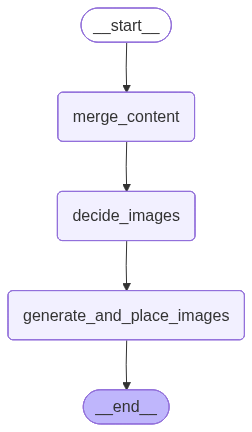

In [24]:
# Sub-Graph for reducer node

reducer_graph = StateGraph(AgentState)


reducer_graph.add_node("merge_content", merge_content)
reducer_graph.add_node("decide_images", decide_images)
reducer_graph.add_node("generate_and_place_images", generate_and_place_images)


reducer_graph.add_edge(START,'merge_content')
reducer_graph.add_edge('merge_content','decide_images')
reducer_graph.add_edge('decide_images','generate_and_place_images')
reducer_graph.add_edge('generate_and_place_images',END)

reducer_graph = reducer_graph.compile()
reducer_graph

In [25]:
builder = StateGraph(AgentState)
builder.add_node('router',router_node)
builder.add_node('research_node',research_node)
builder.add_node('orchestrator_node',orchestrator_node)
builder.add_node('worker',worker_node)
builder.add_node('reducer',reducer_graph)

In [26]:
builder.add_edge(START, 'router')
builder.add_conditional_edges(
    'router',
    route_next,
    {"research": "research_node", "orchestrator": "orchestrator_node"}
)
builder.add_edge('research_node', 'orchestrator_node')
builder.add_conditional_edges("orchestrator_node", fanout, ["worker"])
builder.add_edge('worker', 'reducer')
builder.add_edge('reducer', END)

In [27]:
app = builder.compile()

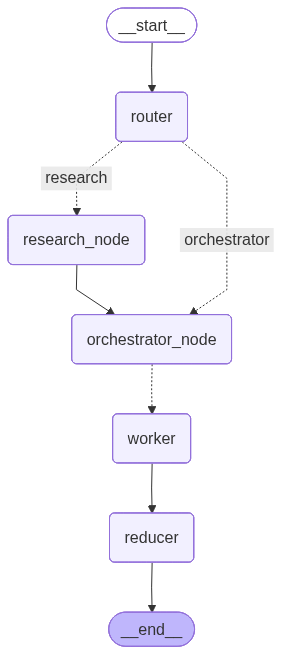

In [28]:
app

In [29]:
input = {
    'topic':'llm',
    'as_of':'',    
}


In [30]:
result = app.stream(input)

In [31]:
for res in result:
    print(res)

[2026-07-04 12:54:55,810]:INFO:llm_factory.py:Loading embedding model — provider: 'google_gemini', model: 'gemini-2.5-flash'
[2026-07-04 12:54:57,045]:INFO:llm_factory.py:LLM model loaded successfully — provider: 'google_gemini', model: 'gemini-2.5-flash'
[2026-07-04 12:54:57,048]:INFO:models.py:AFC is enabled with max remote calls: 10.
[2026-07-04 12:55:00,493]:INFO:_client.py:HTTP Request: POST https://generativelanguage.googleapis.com/v1beta/models/gemini-2.5-flash:generateContent "HTTP/1.1 200 OK"
{'router': {'needs_research': True, 'mode': 'hybrid', 'recency_days': 45, 'queries': ['latest LLM models and their capabilities', 'recent advancements in LLM architecture and training', 'popular LLM application frameworks and libraries 2024', 'enterprise use cases for large language models', 'challenges and limitations of current LLMs', 'ethical considerations for deploying LLMs', 'open-source vs proprietary LLM performance and features', 'LLM fine-tuning techniques and best practices']}}

ChatGoogleGenerativeAIError: Error calling model 'gemini-2.5-flash' (RESOURCE_EXHAUSTED): 429 RESOURCE_EXHAUSTED. {'error': {'code': 429, 'message': 'You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/rate-limits. To monitor your current usage, head to: https://ai.dev/rate-limit. \n* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 5, model: gemini-2.5-flash\nPlease retry in 6.540222628s.', 'status': 'RESOURCE_EXHAUSTED', 'details': [{'@type': 'type.googleapis.com/google.rpc.Help', 'links': [{'description': 'Learn more about Gemini API quotas', 'url': 'https://ai.google.dev/gemini-api/docs/rate-limits'}]}, {'@type': 'type.googleapis.com/google.rpc.QuotaFailure', 'violations': [{'quotaMetric': 'generativelanguage.googleapis.com/generate_content_free_tier_requests', 'quotaId': 'GenerateRequestsPerMinutePerProjectPerModel-Free